# Load traced annotations for pupa CT-scan
CT-scan of P15 pupa from Schoborg & Rusan, in-lab microCT, pixel size ~1.64 microns.
    Link: https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6320925680074752

Tracing done on Neuroglancer, polyline annotations
- Left legs, each leg one json file, each segment a different annotation. Traced contour every 3 slices
- Wing outline. Traced outline every 6 slices
- Pupa outside. Traced outline every 12 slices (except tips)

### Json file structure
Json files saved directly from Neuroglancer. 
Structured as a dictionary - relevant elements below:
- [layers][0] : CT-scan images
- [layers][1:] : Annotations
    - ...[name] : name of the specific annotation (ex. "Left Front leg COXA")
    - ...[annotations][0:] : each one is a polyline, so one contour. Can have several contours on the same slice (for example with the tarsus)
        - ...[points][0:] : each point in the polyline
            - ...[0,1,2] : xyz coordinates

### Neuroglancer links:
LEFT FRONT LEG: 
https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/4929379359522816

LEFT MIDDLE LEG:
https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5735387753349120

LEFT HIND LEG: 
https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6278961163141120

LEFT WING:
https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6035664150724608

PUPA:
https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6078595838509056


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
import pickle

In [2]:
main_path = '/mnt/upramdya_data/MA/Development_project/'
json_folder = os.path.join(main_path, 'CT_PupaP15_traced')
json_list = os.listdir(json_folder)
json_list.sort()
print(json_list)

['Left_Front_leg.json', 'Left_Hind_leg.json', 'Left_Middle_leg.json', 'Left_wing.json', 'Pupa.json', 'pupa_traced_coordinates_rot.pkl', 'pupa_traced_outlines.pkl']


In [3]:
# LOAD COORDINATES
coordinates = {}

for json_file in json_list:
    if not json_file.endswith('.json'):
        continue
    json_path =  os.path.join(json_folder, json_file)

    # Load json file
    with open (json_path, 'r') as f:
        json_data = json.load(f)
        for annotation in json_data['layers'][1:]:
            name = annotation['name']
            coordinates[name] = []
            for polyline in annotation['annotations']:
                points = polyline['points']
                coordinates[name].append(points)
            # concatenate all polylines into a single array
            coordinates[name] = np.concatenate(coordinates[name], axis=0)



names = list(coordinates.keys())
names.sort()

for key in names:
    # add spaces after key names to align the print output
    print(key + " " * (26 - len(key)), end="")
    print(f": {coordinates[key].shape[0]} points")

Left Front leg COXA       : 356 points
Left Front leg FEMUR      : 518 points
Left Front leg TARSUS     : 382 points
Left Front leg TIBIA      : 395 points
Left Front leg TROCHANTER : 97 points
Left Hind leg COXA        : 232 points
Left Hind leg FEMUR       : 634 points
Left Hind leg TARSUS      : 381 points
Left Hind leg TIBIA       : 560 points
Left Hind leg TROCHANTER  : 288 points
Left Mid leg COXA         : 168 points
Left Mid leg FEMUR        : 465 points
Left Mid leg TARSUS       : 256 points
Left Mid leg TIBIA        : 474 points
Left Mid leg TROCHANTER   : 268 points
Left Wing                 : 1557 points
Pupa                      : 5223 points


In [4]:
# set colors for all parts
# for each leg, a different shade of red, green, blue
COLORS = {}
COLORS['Pupa'] = 'gray'
COLORS['Wing'] = 'black'
leg_parts = ['COXA', 'TROCHANTER', 'FEMUR', 'TIBIA', 'TARSUS']

def shade(base, factor):
    """Interpolate base color toward white (factor in [0,1])."""
    base = np.array(base)
    return tuple(base + (1 - base) * factor)

# how light each segment should be
factors = np.linspace(0.0, 0.6, len(leg_parts))  # darker → lighter

for i in range(len(leg_parts)):
    COLORS[f'Front_{leg_parts[i]}'] = shade(mcolors.to_rgb('firebrick'),   factors[i])
    COLORS[f'Mid_{leg_parts[i]}']   = shade(mcolors.to_rgb('yellowgreen'),  factors[i])
    COLORS[f'Hind_{leg_parts[i]}']  = shade(mcolors.to_rgb('dodgerblue'), factors[i])



In [5]:
# set plot order
PLOT_ORDER = []
PLOT_ORDER.append('Pupa')
for leg in ['Hind', 'Mid', 'Front']:
    for part in leg_parts:
        PLOT_ORDER.append(f'Left {leg} leg {part}')
PLOT_ORDER.append('Left Wing')

In [6]:
def plot_pupa(coordinates, plot_what):

    # ensure plot_what is a list
    if isinstance(plot_what, str):
        plot_what = [plot_what]

    # select what to plot - ex: 'Pupa', 'leg', 'Wing', 'Mid'...
    names = PLOT_ORDER
    names_plot = [
        name for name in names
        if any(p in name for p in plot_what)
        ]
    if not names_plot:
        print(f"No names found with {plot_what}")
        return
    
    # get overal xyz lims from coordinates['Pupa']
    xyz_lims = np.array(coordinates['Pupa']).min(axis=0), np.array(coordinates['Pupa']).max(axis=0)

    xyz_combos = [(0,2), (1,2), (0,1)]

    plt.figure(figsize=(7,5))

    for xyz_pair in xyz_combos:
        plt.subplot(1,3,xyz_combos.index(xyz_pair)+1)
        for name in names_plot:

            # find the correct color
            color = 'black'  # default
            for key in COLORS.keys():
                # split by '_' to avoid partial matches
                if '_' in key:
                    key_list = key.split('_')
                else:
                    key_list = [key]
                # check if all parts of the key are in the name
                if all(part in name for part in key_list):
                    color = COLORS[key]
                    break

            plt.scatter(coordinates[name][:,xyz_pair[0]], coordinates[name][:,xyz_pair[1]], s=1, label=name, color=color)

            if xyz_pair == (0,1):
                plt.vlines(0, xyz_lims[0][1], xyz_lims[1][1], colors='black', linestyles='dashed', alpha=0.5)

        plt.xlabel(['X','Y','Z'][xyz_pair[0]])
        plt.ylabel(['X','Y','Z'][xyz_pair[1]])
        plt.gca().set_aspect('equal')
        plt.xlim(xyz_lims[0][xyz_pair[0]], xyz_lims[1][xyz_pair[0]])
        plt.ylim(xyz_lims[0][xyz_pair[1]], xyz_lims[1][xyz_pair[1]])
        if xyz_pair == (0,2):
            plt.title('X-Z plane')
        elif xyz_pair == (1,2):
            plt.title('Y-Z plane')
        elif xyz_pair == (0,1):
            plt.title('X-Y plane')
        if xyz_pair == (0,1):
            plt.legend(bbox_to_anchor=(1.2, 0.5), loc='center left')
    
    plt.plot()


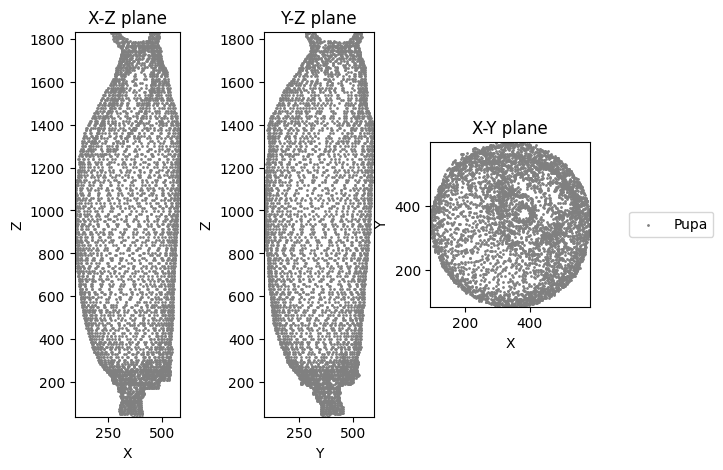

In [7]:
plot_pupa(coordinates, 'Pupa')

In [8]:
# Use pca to align pupa long axis to z axis

# center
X0 = coordinates['Pupa'] - coordinates['Pupa'].mean(axis=0)

# remove top and bottom ()
X0 = X0[(X0[:,2] < 800) & (X0[:,2] > -600)]

# PCA for long axis
pca = PCA(n_components=3)
pca.fit(X0)

# rotate so PC1 → z
R1 = np.vstack([
    pca.components_[1],
    pca.components_[2],
    pca.components_[0],
])

# rotate coordinates to make pupa vertical
coordinates_rot_0 = {}
for key in coordinates.keys():
    X0 = coordinates[key] - coordinates['Pupa'].mean(axis=0)
    X1 = X0 @ R1.T
    coordinates_rot_0[key] = X1

In [9]:
# function to rotate along the X, Y or Z axis
def rotate_around_xyz(mat, angle_deg, xyz='z'):

    angle_rad = np.deg2rad(angle_deg)
    
    c, s = np.cos(angle_rad), np.sin(angle_rad)

    if xyz == 'z':
        Rz = np.array([
            [ c, -s, 0],
            [ s,  c, 0],
            [ 0,  0, 1],
        ])
    elif xyz == 'y':
        Rz = np.array([
            [ c, 0, s],
            [ 0, 1, 0],
            [-s, 0, c],
        ])
    elif xyz == 'x':
        Rz = np.array([
            [1,  0,  0],
            [0,  c, -s],
            [0,  s,  c],
        ])
    else:
        raise ValueError("xyz must be 'x', 'y' or 'z'")

    return mat @ Rz.T

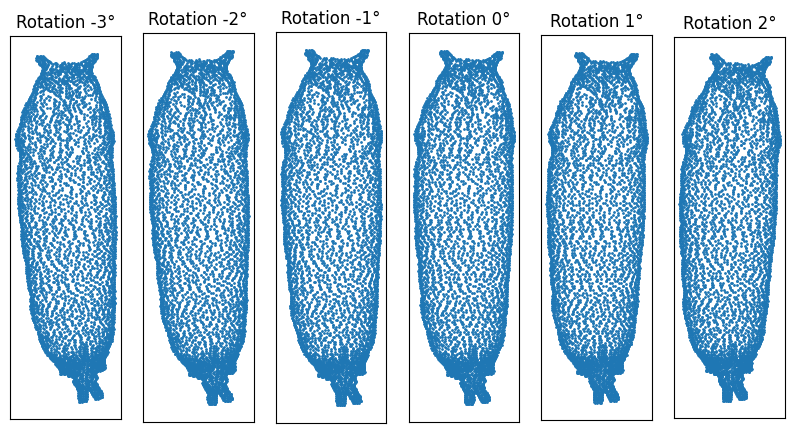

In [10]:
# Manually rotate around Y to determine ideal rotation to align Pupa 

fig, axes = plt.subplots(1,6, figsize=(10,10))
axes = axes.flatten()

start_angle = -3
angles = range(start_angle, start_angle + 6)

for i, theta in enumerate(angles):

    X_rot = rotate_around_xyz(coordinates_rot_0['Pupa'], theta, 'y')

    axes[i].scatter(X_rot[:,0], X_rot[:,2], s=1, label='pca')
    axes[i].set_aspect('equal')
    axes[i].set_title(f'Rotation {theta}°')
    # remove axis labels for clarity
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.show()

In [11]:
# rotate all the coordinates by the selected angle
theta = -0.5

coordinates_rot_1 = {}
for key in coordinates.keys():
    coordinates_rot_1[key] = rotate_around_xyz(coordinates_rot_0[key], theta, 'y')

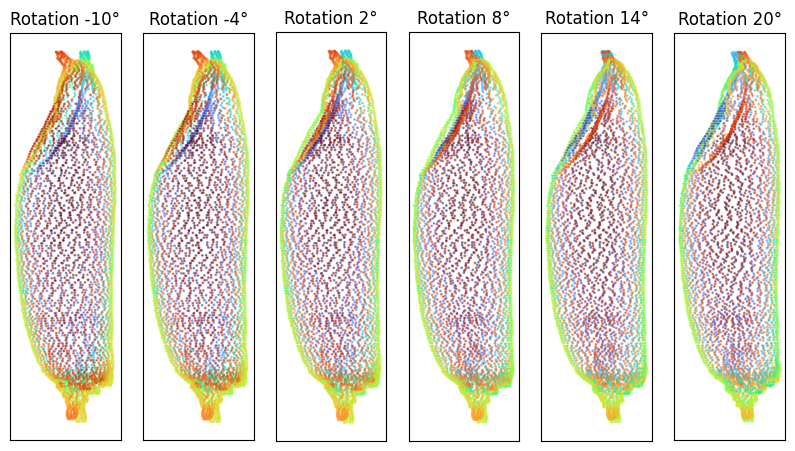

In [12]:
# Manually rotate around Z to determine ideal rotation to align Pupa lateral axis with X axis

fig, axes = plt.subplots(1,6, figsize=(10,10))
axes = axes.flatten()

start_angle = -10
step = 6
angles = range(start_angle, start_angle + 6 * step, step)

for i, theta in enumerate(angles):

    X_rot = rotate_around_xyz(coordinates_rot_1['Pupa'], theta, 'z')
    
    # get alpha based on depth (x)
    depth = X_rot[:,0]
    depth_normalized = (depth - np.min(depth)) / (np.max(depth) - np.min(depth))

    # get color based on depth (x) along a colormap
    colormap = plt.get_cmap('turbo')
    depth_colors = colormap(depth_normalized)

    axes[i].scatter(X_rot[:,1], X_rot[:,2], s=1, label='pca', color=depth_colors, alpha=0.5)
    axes[i].set_aspect('equal')
    axes[i].set_title(f'Rotation {theta}°')
    # remove axis labels for clarity
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.show()

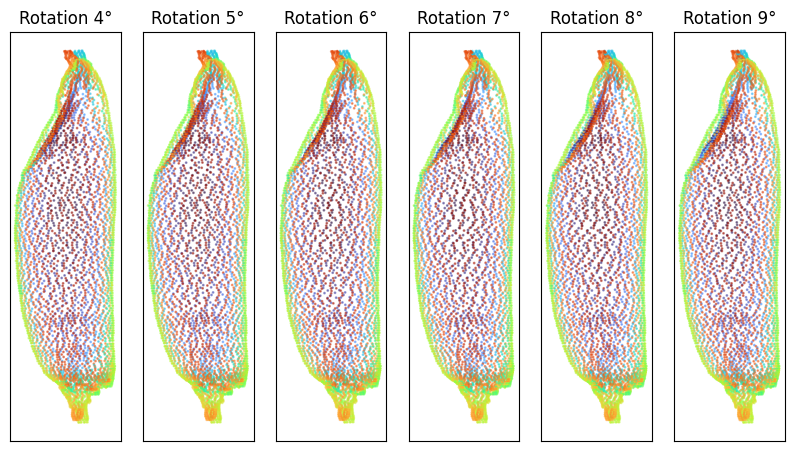

In [13]:
# Manually rotate around Z to determine ideal rotation to align Pupa lateral axis with X axis

fig, axes = plt.subplots(1,6, figsize=(10,10))
axes = axes.flatten()

start_angle = 4
step = 1
angles = range(start_angle, start_angle + 6 * step, step)

for i, theta in enumerate(angles):

    X_rot = rotate_around_xyz(coordinates_rot_1['Pupa'], theta, 'z')

    # get alpha based on depth (x)
    depth = X_rot[:,0]
    depth_normalized = (depth - np.min(depth)) / (np.max(depth) - np.min(depth))

    # get color based on depth (x) along a colormap
    colormap = plt.get_cmap('turbo')
    depth_colors = colormap(depth_normalized)

    axes[i].scatter(X_rot[:,1], X_rot[:,2], s=1, label='pca', color=depth_colors, alpha=0.5)
    axes[i].set_aspect('equal')
    axes[i].set_title(f'Rotation {theta}°')
    # remove axis labels for clarity
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.show()

In [14]:
# rotate all the coordinates by the selected angle
theta = 6

coordinates_rot = {}
for key in coordinates_rot_1.keys():
    coordinates_rot[key] = rotate_around_xyz(coordinates_rot_1[key], theta, 'z')

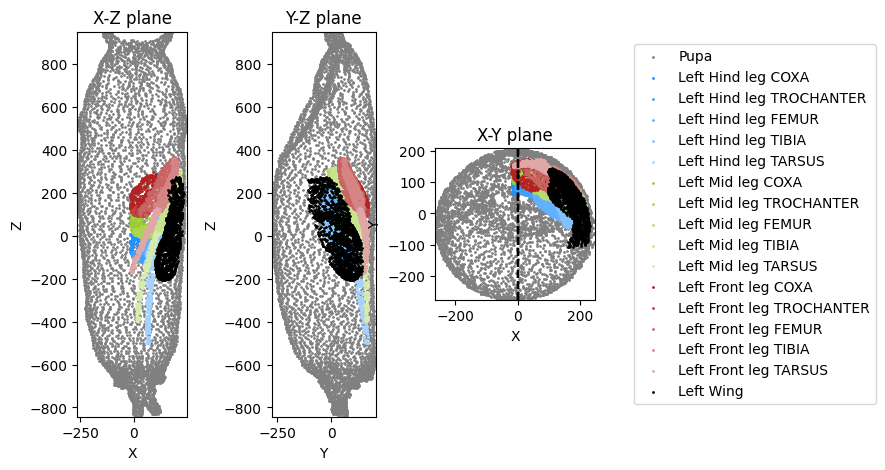

In [15]:
plot_pupa(coordinates_rot, '')

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import shapely.geometry as geom
import shapely.ops as ops
from scipy.spatial import Delaunay

def alpha_shape(points, alpha):
    tri = Delaunay(points)
    edges = set()

    def add_edge(i, j):
        if (i, j) in edges or (j, i) in edges:
            edges.discard((j, i))
        else:
            edges.add((i, j))

    for ia, ib, ic in tri.simplices:
        pa, pb, pc = points[[ia, ib, ic]]
        a = np.linalg.norm(pb - pc)
        b = np.linalg.norm(pa - pc)
        c = np.linalg.norm(pa - pb)
        s = (a + b + c) / 2.0
        area = np.sqrt(max(s*(s-a)*(s-b)*(s-c), 0))
        if area == 0:
            continue
        circum_r = a*b*c / (4.0*area)
        if circum_r < 1.0 / alpha:
            add_edge(ia, ib)
            add_edge(ib, ic)
            add_edge(ic, ia)

    edge_points = [(points[i], points[j]) for i, j in edges]
    m = geom.MultiLineString(edge_points)
    return ops.polygonize(m)


In [17]:
# function to plot OUTLINE of each point-cloud
def plot_outline(coordinates, plot_what, alpha=None, output=False):
    if alpha is None:
        alpha = 0.04  # smaller = tighter boundary

    outlines = {}
    
    # ensure plot_what is a list
    if isinstance(plot_what, str):
        plot_what = [plot_what]

    # select what to plot - ex: 'Pupa', 'leg', 'Wing', 'Mid'...
    names = PLOT_ORDER
    names_plot = [
        name for name in names
        if any(p in name for p in plot_what)
        ]
    if not names_plot:
        print(f"No names found with {plot_what}")
        return
    
    # get overal xyz lims from coordinates['Pupa']
    xyz_lims = np.array(coordinates['Pupa']).min(axis=0), np.array(coordinates['Pupa']).max(axis=0)

    xyz_combos = [(0,2), (1,2), (0,1)]

    plt.figure(figsize=(10,7))

    for xyz_pair in xyz_combos:
        plt.subplot(1,3,xyz_combos.index(xyz_pair)+1)
        for name in names_plot:
            x = coordinates[name][:,xyz_pair[0]]
            y = coordinates[name][:,xyz_pair[1]]

            # find the correct color
            color = 'black'  # default
            for key in COLORS.keys():
                # split by '_' to avoid partial matches
                if '_' in key:
                    key_list = key.split('_')
                else:
                    key_list = [key]
                # check if all parts of the key are in the name
                if all(part in name for part in key_list):
                    color = COLORS[key]
                    break

            points_2d = np.column_stack((x, y))
            polys = list(alpha_shape(points_2d, alpha))
            if len(polys) > 1:
                print(f"Warning: multiple polygons found for {name} in plane {xyz_pair}")

            # save outline polygons as coordinate arrays - only for first xyz_pair
            if xyz_pair == xyz_combos[0]:
                outlines[name] = np.array(polys[0].exterior.coords)

            for poly in polys:
                xs, ys = poly.exterior.xy
                plt.plot(xs, ys, color=color, label=name, linewidth=1)

            if xyz_pair == (0,1):
                plt.vlines(0, xyz_lims[0][1], xyz_lims[1][1], colors='black', linestyles='dashed', alpha=0.5, linewidth=1)

        plt.xlabel(['X','Y','Z'][xyz_pair[0]])
        plt.ylabel(['X','Y','Z'][xyz_pair[1]])
        plt.gca().set_aspect('equal')
        plt.xlim(xyz_lims[0][xyz_pair[0]], xyz_lims[1][xyz_pair[0]])
        plt.ylim(xyz_lims[0][xyz_pair[1]], xyz_lims[1][xyz_pair[1]])
        if xyz_pair == (0,2):
            plt.title('X-Z plane')
        elif xyz_pair == (1,2):
            plt.title('Y-Z plane')
        elif xyz_pair == (0,1):
            plt.title('X-Y plane')
        if xyz_pair == (0,1):
            plt.legend(bbox_to_anchor=(1.2, 0.5), loc='center left')
    
    plt.show()

    if output:
        return outlines

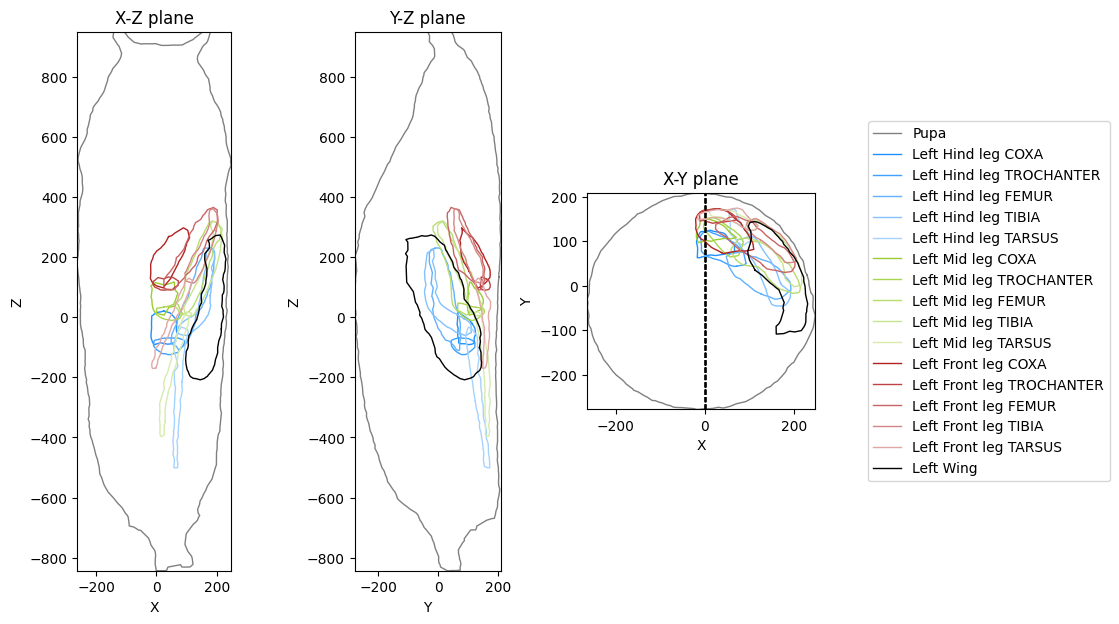

In [18]:
outlines = plot_outline(coordinates_rot, '', output=True)

In [19]:
# save outlines of all parts to pickle file
save_path = os.path.join(json_folder, 'pupa_traced_outlines.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(outlines, f)

In [20]:
# save coordinates_rot to pickle file
save_path = os.path.join(json_folder, 'pupa_traced_coordinates_rot.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(coordinates_rot, f)